# Processing ocean forcing data for ISMIP6 AIS 2300

This notebook loads the ocean forcing data and model simulations to calculate the thermal driving at the ice shelf draft, this is used in the melt parameterisation as input

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import math as ma
#import gsw

In [2]:
forcing_data_path = '/media/ronja/Elements/ISMIP6_data/'
projections_data_path = '/media/ronja/Elements/ISMIP6_data/'

In [3]:
# Example experiment and corresponding ocean forcing names this can be drawn from the INFOS Dataframe
experiment = 'expAE02'
climate_model = 'ukesm1-0-ll_ssp585'
name = 'UKESM1-0-LL_SSP585'

In [4]:
# Example model simulation, this can be used from the INFOS dataframe
model = 'PIK_PISM'

# Load ice draft 

In [5]:
draft = xr.open_dataset(projections_data_path+"/"+model+"/"+experiment+'_8/base_AIS_'+model+'_'+experiment+'.nc')

draft

/home/ronja/anaconda3/lib/python3.8/site-packages/xarray/coding/times.py:526: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/ronja/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return array(a, dtype, copy=False, order=order)


<xarray.Dataset>
Dimensions:    (nv: 2, time: 286, x: 761, y: 761)
Coordinates:
  * x          (x) float32 -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y          (y) float32 -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * time       (time) object 2016-01-01 00:00:00 ... 2301-01-01 00:00:00
Dimensions without coordinates: nv
Data variables:
    base       (time, y, x) float32 ...
    mapping    float64 ...
    time_bnds  (time, nv) object ...
Attributes:
    Conventions:  CF-1.6
    source:       PISM (stable v1.0-1845-gf0ec2d914 committed by ronjareese o...
    institution:  Potsdam Institute for Climate Impact Research (PIK), Germany
    contact:      akklose@pik-potsdam.de
    title:        ISMIP6 AIS Projections

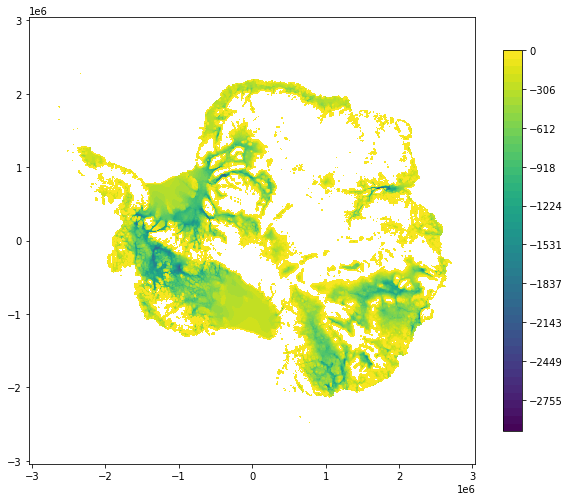

In [6]:
# Take a look at the draft
plt.figure(figsize=(10,10))
plt.contourf(draft.get('x'),draft.get('y'),draft.get('base').values[0], 
           # levels=[0.5,1.5, 2.5, 3.5], #colors='black'
             vmin=-3000,vmax=0, levels=np.linspace(-3000,0)
            )
plt.colorbar(shrink=0.7)
plt.gca().set_aspect("equal")

# Get ocean forcing data

In [7]:
tf = xr.open_dataset(
    forcing_data_path+climate_model+"/1995-2300/"+name+"_thermal_forcing_8km_x_60m.nc")

tf

<xarray.Dataset>
Dimensions:          (nbounds: 2, time: 306, x: 761, y: 761, z: 30)
Coordinates:
  * x                (x) float64 -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y                (y) float64 -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * z                (z) float64 -30.0 -90.0 -150.0 ... -1.71e+03 -1.77e+03
  * time             (time) object 1995-01-01 00:00:00 ... 2300-01-01 00:00:00
Dimensions without coordinates: nbounds
Data variables:
    z_bnds           (time, z, nbounds) float64 ...
    thermal_forcing  (time, z, y, x) float32 ...

In [8]:
# Get the time from the forcing

time_forcing = np.empty(len(tf['time'].values))
for i in range(len(tf['time'].values)):
    time_forcing[i] = (int(tf['time'].values[i].strftime().split('-')[0]))

time_forcing

array([1995., 1996., 1997., 1998., 1999., 2000., 2001., 2002., 2003.,
       2004., 2005., 2006., 2007., 2008., 2009., 2010., 2011., 2012.,
       2013., 2014., 2015., 2016., 2017., 2018., 2019., 2020., 2021.,
       2022., 2023., 2024., 2025., 2026., 2027., 2028., 2029., 2030.,
       2031., 2032., 2033., 2034., 2035., 2036., 2037., 2038., 2039.,
       2040., 2041., 2042., 2043., 2044., 2045., 2046., 2047., 2048.,
       2049., 2050., 2051., 2052., 2053., 2054., 2055., 2056., 2057.,
       2058., 2059., 2060., 2061., 2062., 2063., 2064., 2065., 2066.,
       2067., 2068., 2069., 2070., 2071., 2072., 2073., 2074., 2075.,
       2076., 2077., 2078., 2079., 2080., 2081., 2082., 2083., 2084.,
       2085., 2086., 2087., 2088., 2089., 2090., 2091., 2092., 2093.,
       2094., 2095., 2096., 2097., 2098., 2099., 2100., 2101., 2102.,
       2103., 2104., 2105., 2106., 2107., 2108., 2109., 2110., 2111.,
       2112., 2113., 2114., 2115., 2116., 2117., 2118., 2119., 2120.,
       2121., 2122.,

Text(0.5, 1.0, 'Thermal forcing at time=1995-01-01 00:00:00 and depth=-930.0 m')

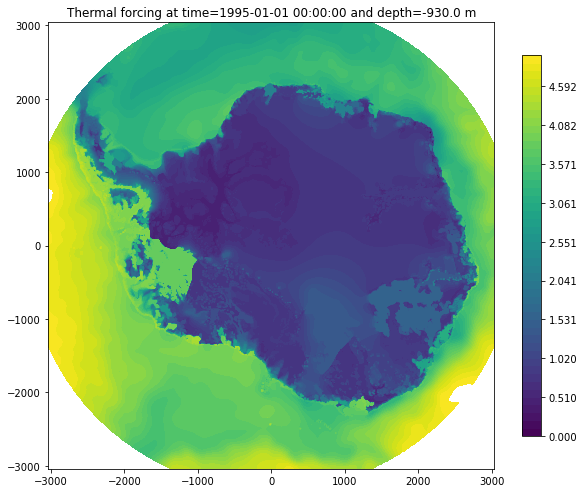

In [9]:
# Plot forcing at some time and depth level

time_id = 0
z_level = 15


plt.figure(figsize=(10,10))
plt.contourf(tf.get('x')/1e3,tf.get('y')/1e3,tf['thermal_forcing'][time_id][z_level].values, 
           # levels=[0.5,1.5, 2.5, 3.5], #colors='black'
             vmin=0,vmax=5, levels=np.linspace(0,5)
            )
plt.colorbar(shrink=0.7)
plt.gca().set_aspect("equal")
plt.title('Thermal forcing at time='+str(tf['time'].values[time_id])+' and depth='+str(tf['z'].values[z_level])+' m')

# Load floating mask

In [10]:
mask_floating='sftflf_AIS_'+model+'_'+experiment+'.nc'

# FIXME: we might need to remove the 8 here
d = xr.open_dataset(projections_data_path+"/"+model+"/"+experiment+'_8/'+mask_floating)

time_model = np.empty(len(d['time'].values))
for i in range(len(d['time'].values)):
    time_model[i] = (int(d.sftflf['time'].values[i].strftime().split('-')[0]))

/home/ronja/anaconda3/lib/python3.8/site-packages/xarray/coding/times.py:526: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


# Sample the ocean forcing at the draft depth 

This is an exmaple here for one time step

In [13]:
zbnd = tf.get('z_bnds').values[0,:]

# FIXME: eventually, we want to loop here over time
timei = 150
time = time_model[timei]
print('Year='+str(time))

m_in=d.sftflf.values[timei,]
m = m_in >0
shelf_draft =draft.base.values[timei,]
shelf_draft[~m]=100

shelf_draft_bin = np.empty(shelf_draft.shape)
shelf_draft_bin[:] = np.nan

# This will be the relevant thermal forcing
shelf_draft_bin_temp = np.empty(shelf_draft.shape)
shelf_draft_bin_temp[:] = np.nan

# create a mask of the depth indices of the shelf draft
for i,zbnd_i in enumerate(zbnd):
    zmax = zbnd_i[0]
    zmin = zbnd_i[-1]
    ind_mask = np.nonzero(np.logical_and(shelf_draft<zmax, shelf_draft>=zmin))
    shelf_draft_bin[ind_mask] = i 
    
    
# find the correct time for the thermal forcing
timeif = np.argwhere(time_forcing==time_model[timei])[0][0]
print(time_forcing[timeif])


# Find the thermal forcing at the correct depth
tf_time = tf.thermal_forcing[timeif].values
for i,z in enumerate(tf.thermal_forcing.z.values):
    maski = shelf_draft_bin==i
    shelf_draft_bin_temp[maski] = tf_time[i,maski]
    

Year=2166.0
2166.0


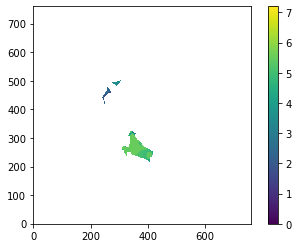

In [14]:
# Show the resulting temperature field
plt.imshow(shelf_draft_bin_temp, origin='lower') #, vmin=0, vmax=6)
plt.colorbar()

# Next steps

As next steps, we want to calculate the thermal forcing averged over certain regions / basins
We want to have this for the entire basin, in a certain region of the grounding line, and over certain depths bins
